# 01b · Geometría DICOM: posiciones de corte, espaciado y medidas

En este cuaderno desarrollo el punto del Laboratorio 1 ("ordene por
`ImagePositionPatient`, mida el espaciado efectivo, compárelo con `SliceThickness`,
corrija la relación de aspecto y cuantifique el error") sobre los datos del proyecto, para
PET y CT. El desarrollo escrito está en `docs/GEOMETRIA_DICOM.md`; aquí lo ejecuto.

Trabajo con lo que haya en `data/raw`. Con tres pacientes ya se ve todo; con los 251 la
tabla final pasa a ser la estadística de la colección. Si no hubiera datos reales, el
cuaderno usa el fantoma sintético para que ninguna celda falle.

In [1]:
import sys, glob, tempfile
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pydicom, SimpleITK as sitk

RAIZ = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src")); sys.path.insert(0, str(RAIZ / "tests"))
from petct.geometry import series_geometry, index_to_mm, measurement_error_if_aspect_ignored
import synthetic

series_csv = RAIZ / "data/manifests/series_tcia.csv"
raw = RAIZ / "data/raw"
reales = series_csv.exists() and raw.exists() and any(p.is_dir() for p in raw.iterdir())
if reales:
    ser = pd.read_csv(series_csv)
    ser = ser[ser.Modality.isin(["CT", "PT"]) & ser.SeriesInstanceUID.map(lambda u: (raw / str(u)).exists())]
    carpetas = {(r.PatientID, r.Modality): raw / str(r.SeriesInstanceUID) for _, r in ser.iterrows()}
    print(f"{len(carpetas)} series reales de {ser.PatientID.nunique()} pacientes")
else:
    tmp = Path(tempfile.mkdtemp(prefix="geo_")); synthetic.make_phantom(tmp)
    carpetas = {("FANTOMA", "CT"): tmp / "CT", ("FANTOMA", "PT"): tmp / "PT"}
    print("sin datos reales: usando el fantoma sintético")

502 series reales de 251 pacientes


## 1. Leer la cabecera de un corte

Cada archivo DICOM lleva, además de los píxeles, la ficha con su geometría. Con cuatro
atributos ubico cualquier píxel en el espacio del paciente: la posición del primer píxel
(`ImagePositionPatient`), la orientación de filas y columnas (`ImageOrientationPatient`),
el tamaño del píxel (`PixelSpacing`) y el grosor del corte (`SliceThickness`). Abro el
primer archivo de una serie PET y de una CT.

In [2]:
def ficha(folder):
    f = sorted(p for p in Path(folder).iterdir() if p.suffix == ".dcm")[0]
    ds = pydicom.dcmread(str(f), stop_before_pixels=True)
    campos = ["Modality", "PatientPosition", "Rows", "Columns", "PixelSpacing", "SliceThickness",
              "SpacingBetweenSlices", "ImagePositionPatient", "ImageOrientationPatient",
              "InstanceNumber", "SliceLocation", "FrameOfReferenceUID"]
    return {c: ds.get(c, "(ausente)") for c in campos}

for (pid, mod), folder in list(carpetas.items())[:2]:
    print(f"== {pid} {mod}")
    for k, v in ficha(folder).items():
        print(f"   {k:24s} {str(v)[:70]}")

== PETCT_ee97822c60 PT
   Modality                 PT
   PatientPosition          HFS
   Rows                     400
   Columns                  400
   PixelSpacing             [2.03642, 2.03642]
   SliceThickness           3
   SpacingBetweenSlices     (ausente)
   ImagePositionPatient     [-406.738, -635.483, -1331.5]
   ImageOrientationPatient  [1, 0, 0, 0, 1, 0]
   InstanceNumber           1
   SliceLocation            -1331.5
   FrameOfReferenceUID      1.3.6.1.4.1.14519.5.2.1.4219.6651.150407402920963321417450259235
== PETCT_ee97822c60 CT
   Modality                 CT
   PatientPosition          HFS
   Rows                     512
   Columns                  512
   PixelSpacing             [0.828125, 0.828125]
   SliceThickness           3
   SpacingBetweenSlices     (ausente)
   ImagePositionPatient     [-205.5859375, -423.0859375, -356.5]
   ImageOrientationPatient  [1, 0, 0, 0, 1, 0]
   InstanceNumber           1
   SliceLocation            -356.5
   FrameOfReferenceUID     

`SpacingBetweenSlices` aparece como ausente: la distancia entre cortes no está declarada
y tengo que medirla. `PatientPosition = HFS` (cabeza primero, decúbito supino) dice cómo
entró el paciente al equipo. Y `FrameOfReferenceUID` es el mismo para PET y CT del mismo
estudio: comparten origen y ejes, por eso se superponen por milímetros.

## 2. El orden de los cortes

La advertencia del laboratorio es que el orden alfabético no garantiza el orden
anatómico. Para comprobarlo leo la posición z de cada archivo en el orden en que vienen
nombrados. `series_geometry` hace además el ordenamiento correcto: proyecta cada posición
sobre la normal al plano (producto cruz de los dos vectores de orientación) y ordena por
ese número.

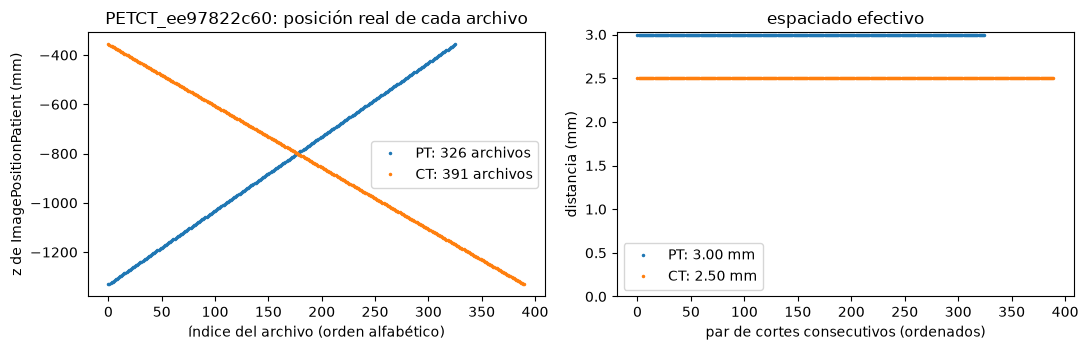

In [3]:
def z_por_nombre(folder):
    zs = []
    for f in sorted(p for p in Path(folder).iterdir() if p.is_file() and not p.name.startswith(".")):
        try:
            zs.append(float(pydicom.dcmread(str(f), stop_before_pixels=True).ImagePositionPatient[2]))
        except Exception:      # cada carpeta de TCIA trae un archivo LICENSE
            pass
    return np.array(zs)

pid0 = list(carpetas)[0][0]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for mod in ("PT", "CT"):
    z = z_por_nombre(carpetas[(pid0, mod)])
    ax[0].plot(z, ".", ms=3, label=f"{mod}: {len(z)} archivos")
    ax[1].plot(np.diff(np.sort(z)), ".", ms=3, label=f"{mod}: {np.diff(np.sort(z)).mean():.2f} mm")
ax[0].set_xlabel("índice del archivo (orden alfabético)"); ax[0].set_ylabel("z de ImagePositionPatient (mm)"); ax[0].legend(); ax[0].set_title(f"{pid0}: posición real de cada archivo")
ax[1].set_xlabel("par de cortes consecutivos (ordenados)"); ax[1].set_ylabel("distancia (mm)"); ax[1].legend(); ax[1].set_title("espaciado efectivo"); ax[1].set_ylim(0, None)
plt.tight_layout(); plt.show()

En autoPET el PET viene de los pies a la cabeza y el CT de la cabeza a los pies. El nombre
y el `InstanceNumber` coinciden entre sí en ambos, así que ninguno me sirve como criterio
general. La única regla robusta es la posición física, que es la que usa SimpleITK al leer
una serie y la que uso en `convert.py`.

## 3. Grosor frente a espaciado

Son dos cosas distintas: el grosor es cuánto tejido promedia cada corte reconstruido; el
espaciado es cada cuántos milímetros hay un corte. En la tabla los pongo lado a lado para
todas las series disponibles, junto con el campo de visión y la relación de aspecto.

In [4]:
filas = []
for (pid, mod), folder in carpetas.items():
    g = series_geometry(folder); g.pop("positions_sorted_mm"); g["patient_id"] = pid; filas.append(g)
geo = pd.DataFrame(filas)
cols = ["patient_id", "modality", "n_slices", "rows", "row_spacing_mm", "fov_rows_mm", "slice_thickness_mm",
        "gap_mean_mm", "gap_min_mm", "gap_max_mm", "uniform", "extent_mm", "order_by_name_ok", "aspect_coronal"]
geo["solape_mm"] = (geo.slice_thickness_mm - geo.gap_mean_mm).round(2)
display(geo[cols + ["solape_mm"]].round(3))

,patient_id,modality,n_slices,rows,row_spacing_mm,fov_rows_mm,slice_thickness_mm,gap_mean_mm,gap_min_mm,gap_max_mm,uniform,extent_mm,order_by_name_ok,aspect_coronal,solape_mm
0,PETCT_ee97822c60,PT,326,400,2.036,814.568,3.0,3.0,3.0,3.0,True,978.0,True,1.473,0.0
1,PETCT_ee97822c60,CT,391,512,0.828,424.000,3.0,2.5,2.5,2.5,True,978.0,False,3.019,0.5
2,PETCT_efd619ecbf,PT,284,400,2.036,814.568,3.0,3.0,3.0,3.0,True,852.0,True,1.473,0.0
3,PETCT_efd619ecbf,CT,340,512,0.809,414.000,3.0,2.5,2.5,2.5,True,850.5,False,3.092,0.5
4,PETCT_f144b214af,CT,978,512,0.896,459.000,2.0,1.0,1.0,1.0,True,979.0,False,1.115,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,PETCT_0117d7f11f,CT,852,512,0.758,388.000,2.0,1.0,1.0,1.0,True,853.0,False,1.320,1.0
498,PETCT_01682f60c3,PT,326,400,2.036,814.568,3.0,3.0,3.0,3.0,True,978.0,True,1.473,0.0
499,PETCT_01682f60c3,CT,978,512,0.795,407.000,2.0,1.0,1.0,1.0,True,979.0,False,1.258,1.0
500,PETCT_04606080a0,PT,284,400,2.036,814.568,3.0,3.0,3.0,3.0,True,852.0,True,1.473,0.0


Mi lectura: en el PET grosor y espaciado coinciden (3 mm cada 3 mm, contiguos). En el CT
el grosor es mayor que el espaciado: reconstrucción con solape, habitual en CT helicoidal.
No es un error de los datos; el error sería usar el grosor para armar el volumen. Con la
colección completa descargada, esta misma tabla me dice cuántos CT vienen con cada
combinación de grosor y espaciado, que es un dato para la sección de materiales del
informe.

## 4. De índices a milímetros

La ecuación del módulo Image Plane: la posición de la fila i, columna j del corte k es el
origen del corte más j veces el espaciado de columnas en la dirección de las columnas, más
i veces el espaciado de filas en la dirección de las filas. Es una transformación afín, la
misma que guardan SimpleITK (origen, espaciado, dirección) y NIfTI. La aplico a la serie
PET para ubicar el vóxel del centro del primer corte.

In [5]:
g = series_geometry(carpetas[(pid0, "PT")])
col_dir, row_dir = np.array(g["iop"][:3]), np.array(g["iop"][3:])
p = index_to_mm(g["rows"] // 2, g["cols"] // 2, 0, g["origin_first_slice"], g["row_spacing_mm"], g["col_spacing_mm"],
                col_dir, row_dir, g["normal"], g["gap_mean_mm"])
print("origen del primer corte (mm):", g["origin_first_slice"])
print("centro del primer corte (mm): ", p.round(1))
print("normal al corte:", g["normal"], "→ cada corte siguiente está", g["gap_mean_mm"], "mm más arriba (z crece hacia la cabeza)")

origen del primer corte (mm): [-406.738, -635.483, -1331.5]
centro del primer corte (mm):  [ 5.0000e-01 -2.2820e+02 -1.3315e+03]
normal al corte: [0.0, 0.0, 1.0] → cada corte siguiente está 3.0 mm más arriba (z crece hacia la cabeza)


## 5. Relación de aspecto y el error que se comete al ignorarla

En una vista coronal o sagital el eje vertical es z. Si dibujo el arreglo con píxeles
cuadrados, cada corte ocupa un píxel de alto aunque mida 3 mm. El factor de corrección es
Δz / Δplano. El error de medida para un segmento vertical es directo: aparece con longitud
L · Δplano / Δz. Para un segmento oblicuo el error depende del ángulo; la función lo
calcula para cualquier caso, y aquí lo evalúo para cada serie.

PETCT_ee97822c60 PT: aspecto 1.47 | un segmento vertical de 30 mm 'mide' 20.4 mm (-32%); a 45°, 25.6 mm (-15%)
PETCT_ee97822c60 CT: aspecto 3.02 | un segmento vertical de 30 mm 'mide' 9.9 mm (-67%); a 45°, 22.3 mm (-26%)
PETCT_efd619ecbf PT: aspecto 1.47 | un segmento vertical de 30 mm 'mide' 20.4 mm (-32%); a 45°, 25.6 mm (-15%)
PETCT_efd619ecbf CT: aspecto 3.09 | un segmento vertical de 30 mm 'mide' 9.7 mm (-68%); a 45°, 22.3 mm (-26%)
PETCT_f144b214af CT: aspecto 1.12 | un segmento vertical de 30 mm 'mide' 26.9 mm (-10%); a 45°, 28.5 mm (-5%)
PETCT_f144b214af PT: aspecto 1.47 | un segmento vertical de 30 mm 'mide' 20.4 mm (-32%); a 45°, 25.6 mm (-15%)
PETCT_f21755a99b CT: aspecto 2.99 | un segmento vertical de 30 mm 'mide' 10.0 mm (-67%); a 45°, 22.4 mm (-25%)
PETCT_f21755a99b PT: aspecto 1.47 | un segmento vertical de 30 mm 'mide' 20.4 mm (-32%); a 45°, 25.6 mm (-15%)
PETCT_f2f28337ba CT: aspecto 1.25 | un segmento vertical de 30 mm 'mide' 24.0 mm (-20%); a 45°, 27.2 mm (-9%)
PETCT

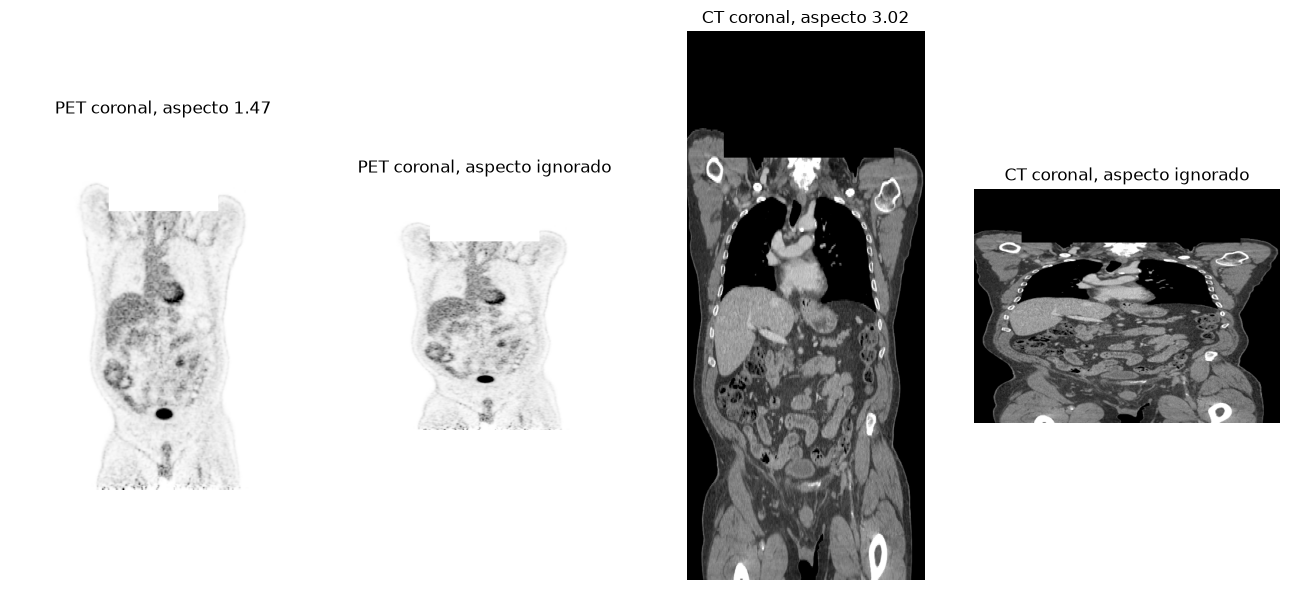

In [6]:
for _, r in geo.iterrows():
    e90 = measurement_error_if_aspect_ignored(30, 90, r.row_spacing_mm, r.gap_mean_mm)
    e45 = measurement_error_if_aspect_ignored(30, 45, r.row_spacing_mm, r.gap_mean_mm)
    print(f"{r.patient_id} {r.modality}: aspecto {r.aspect_coronal:.2f} | un segmento vertical de 30 mm 'mide' {30*(1+e90):.1f} mm ({e90:+.0%}); a 45°, {30*(1+e45):.1f} mm ({e45:+.0%})")

# vistas coronal y sagital con y sin corrección, del primer paciente (desde los NIfTI si existen)
nii = sorted((RAIZ / "data/interim/nifti").glob(f"{pid0}/*/SUV.nii.gz")) if reales else []
if nii:
    suv = sitk.ReadImage(str(nii[0])); ct = sitk.ReadImage(str(nii[0].parent / "CT.nii.gz"))
    A, C = sitk.GetArrayFromImage(suv), sitk.GetArrayFromImage(ct)
    sp, sc = suv.GetSpacing(), ct.GetSpacing()
    fig, ax = plt.subplots(1, 4, figsize=(13, 6))
    ax[0].imshow(np.flipud(A[:, A.shape[1]//2, :]), cmap="gray_r", vmin=0, vmax=6, aspect=sp[2]/sp[0]); ax[0].set_title(f"PET coronal, aspecto {sp[2]/sp[0]:.2f}")
    ax[1].imshow(np.flipud(A[:, A.shape[1]//2, :]), cmap="gray_r", vmin=0, vmax=6, aspect=1); ax[1].set_title("PET coronal, aspecto ignorado")
    ax[2].imshow(np.flipud(C[:, C.shape[1]//2, :]), cmap="gray", vmin=-200, vmax=300, aspect=sc[2]/sc[0]); ax[2].set_title(f"CT coronal, aspecto {sc[2]/sc[0]:.2f}")
    ax[3].imshow(np.flipud(C[:, C.shape[1]//2, :]), cmap="gray", vmin=-200, vmax=300, aspect=1); ax[3].set_title("CT coronal, aspecto ignorado")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("(las vistas coronales se muestran cuando existen los NIfTI del Paso 1)")

La cabeza va arriba en las figuras porque volteo el eje z para dibujar: en el arreglo, el
índice 0 es el corte más inferior.

## 6. La segmentación es distinta: un solo archivo con muchos frames

El DICOM SEG de autoPET trae los 284 cortes de la máscara como frames de un único objeto,
cada uno con su propia posición, y con las filas recorridas al revés que el PET
(`ImageOrientationPatient` 1,0,0,0,−1,0). Si apilara los frames sin mirar la
orientación, la máscara quedaría reflejada; me pasó en la primera conversión y lo
documenté en la bitácora. El fantoma sintético reproduce ese caso y la conversión lo
resuelve ubicando las dos esquinas físicas de cada frame en la grilla del PET. Aquí
muestro la cabecera de un SEG real.

In [7]:
seg_ds = None
if reales:
    for d in sorted(p for p in raw.iterdir() if p.is_dir()):
        dcms = sorted(d.glob("*.dcm"))
        if len(dcms) == 1:                      # el SEG es un solo archivo multiframe
            ds = pydicom.dcmread(str(dcms[0]), stop_before_pixels=True)
            if ds.Modality == "SEG":
                seg_ds = ds; break
if seg_ds is not None:
    sh = seg_ds.SharedFunctionalGroupsSequence[0]
    fr = seg_ds.PerFrameFunctionalGroupsSequence
    print("frames:", seg_ds.NumberOfFrames, "| Rows x Cols:", seg_ds.Rows, "x", seg_ds.Columns)
    print("orientación compartida:", list(sh.PlaneOrientationSequence[0].ImageOrientationPatient))
    print("PixelSpacing compartido:", list(sh.PixelMeasuresSequence[0].PixelSpacing))
    print("posición de los 3 primeros frames:", [list(map(float, fg.PlanePositionSequence[0].ImagePositionPatient)) for fg in fr[:3]])
    print("segmentos:", [s.SegmentLabel for s in seg_ds.SegmentSequence])
else:
    print("sin SEG real disponible; ver tests/synthetic.py::write_seg para el caso reproducido")

frames: 409 | Rows x Cols: 400 x 400
orientación compartida: ['1', '0', '0', '0', '1', '0']
PixelSpacing compartido: ['2.036420e+000', '2.036420e+000']
posición de los 3 primeros frames: [[-405.852997, -661.088989, 211.0], [-405.852997, -661.088989, 214.0], [-405.852997, -661.088989, 217.0]]
segmentos: ['Tissue']


## Lo que anoto en la bitácora

Con la descarga completa: cuántas series CT vienen con cada grosor y espaciado, si alguna
no es uniforme, cuántos pacientes tienen un campo de visión de CT que no cubre los brazos,
y si aparece alguna serie con orientación distinta de la axial pura. Esa es la
descripción geométrica de los datos para el informe.